In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:/Users/DELL/Desktop/Portfolio Projects/5 - Predict Stock Prices\Datasets/NIFTY50_all.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [3]:
df.set_index("Date",inplace=True)

## Plotting the target variable VWAP over time

<AxesSubplot:xlabel='Date'>

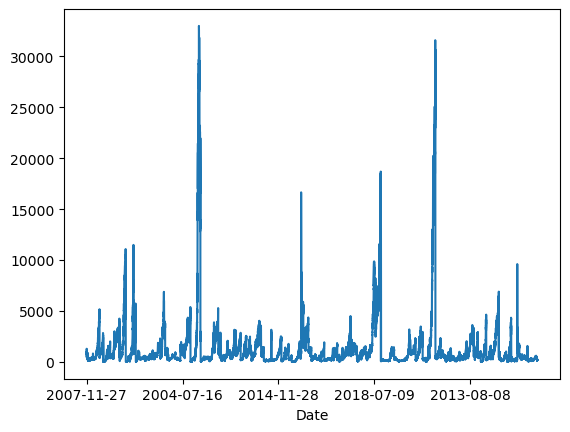

In [4]:
df['VWAP'].plot()

## Data Preprocessing

In [5]:
df.shape

(235192, 14)

In [6]:
df.isna().sum()

Symbol                     0
Series                     0
Prev Close                 0
Open                       0
High                       0
Low                        0
Last                       0
Close                      0
VWAP                       0
Volume                     0
Turnover                   0
Trades                114848
Deliverable Volume     16077
%Deliverble            16077
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.isna().sum()

Symbol                0
Series                0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
%Deliverble           0
dtype: int64

In [9]:
df.shape

(120344, 14)

In [10]:
data = df.copy()

In [11]:
data.dtypes

Symbol                 object
Series                 object
Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume    float64
%Deliverble           float64
dtype: object

In [12]:
data.columns

Index(['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

In [13]:
data[["Open","High","Low","Close"]].corr()

,Open,High,Low,Close
Open,1.000000,0.999867,0.999882,0.999781
High,0.999867,1.000000,0.999821,0.999907
Low,0.999882,0.999821,1.000000,0.999891
Close,0.999781,0.999907,0.999891,1.000000


In [14]:
lag_features=['High','Low','Volume','Turnover','Trades']
window1=3
window2=7

In [15]:
for feature in lag_features:
    data[feature+'rolling_mean_3']=data[feature].rolling(window=window1).mean()
    data[feature+'rolling_mean_7']=data[feature].rolling(window=window2).mean()

In [16]:
for feature in lag_features:
    data[feature+'rolling_std_3']=data[feature].rolling(window=window1).std()
    data[feature+'rolling_std_7']=data[feature].rolling(window=window2).std()

In [17]:
data.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Highrolling_std_3,Highrolling_std_7,Lowrolling_std_3,Lowrolling_std_7,Volumerolling_std_3,Volumerolling_std_7,Turnoverrolling_std_3,Turnoverrolling_std_7,Tradesrolling_std_3,Tradesrolling_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2011-06-01,MUNDRAPORT,EQ,161.45,162.10,165.70,161.25,163.50,164.00,164.08,2574106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-06-02,MUNDRAPORT,EQ,164.00,164.00,165.15,160.15,161.15,161.25,162.17,1699298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-06-03,MUNDRAPORT,EQ,161.25,161.50,162.80,159.20,161.00,161.05,161.02,1185817,...,1.540292,NaN,1.025914,NaN,701937.571031,NaN,1.171006e+13,NaN,2230.631525,NaN
2011-06-06,MUNDRAPORT,EQ,161.05,160.50,161.10,159.05,160.00,159.85,160.09,546378,...,2.033675,NaN,0.596518,NaN,577605.617828,NaN,9.420641e+12,NaN,4910.178238,NaN
2011-06-07,MUNDRAPORT,EQ,159.85,159.85,162.75,156.35,157.00,157.25,158.52,2193466,...,0.967385,NaN,1.603901,NaN,830375.178425,NaN,1.310234e+13,NaN,5563.805382,NaN


In [18]:
data.columns

Index(['Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble', 'Highrolling_mean_3', 'Highrolling_mean_7',
       'Lowrolling_mean_3', 'Lowrolling_mean_7', 'Volumerolling_mean_3',
       'Volumerolling_mean_7', 'Turnoverrolling_mean_3',
       'Turnoverrolling_mean_7', 'Tradesrolling_mean_3',
       'Tradesrolling_mean_7', 'Highrolling_std_3', 'Highrolling_std_7',
       'Lowrolling_std_3', 'Lowrolling_std_7', 'Volumerolling_std_3',
       'Volumerolling_std_7', 'Turnoverrolling_std_3', 'Turnoverrolling_std_7',
       'Tradesrolling_std_3', 'Tradesrolling_std_7'],
      dtype='object')

In [19]:
data.isna().sum()

Symbol                    0
Series                    0
Prev Close                0
Open                      0
High                      0
Low                       0
Last                      0
Close                     0
VWAP                      0
Volume                    0
Turnover                  0
Trades                    0
Deliverable Volume        0
%Deliverble               0
Highrolling_mean_3        2
Highrolling_mean_7        6
Lowrolling_mean_3         2
Lowrolling_mean_7         6
Volumerolling_mean_3      2
Volumerolling_mean_7      6
Turnoverrolling_mean_3    2
Turnoverrolling_mean_7    6
Tradesrolling_mean_3      2
Tradesrolling_mean_7      6
Highrolling_std_3         2
Highrolling_std_7         6
Lowrolling_std_3          2
Lowrolling_std_7          6
Volumerolling_std_3       2
Volumerolling_std_7       6
Turnoverrolling_std_3     2
Turnoverrolling_std_7     6
Tradesrolling_std_3       2
Tradesrolling_std_7       6
dtype: int64

In [20]:
data.dropna(inplace=True)

In [21]:
ind_features=['Highrolling_mean_3', 'Highrolling_mean_7',
       'Lowrolling_mean_3', 'Lowrolling_mean_7', 'Volumerolling_mean_3',
       'Volumerolling_mean_7', 'Turnoverrolling_mean_3',
       'Turnoverrolling_mean_7', 'Tradesrolling_mean_3',
       'Tradesrolling_mean_7', 'Highrolling_std_3', 'Highrolling_std_7',
       'Lowrolling_std_3', 'Lowrolling_std_7', 'Volumerolling_std_3',
       'Volumerolling_std_7', 'Turnoverrolling_std_3', 'Turnoverrolling_std_7',
       'Tradesrolling_std_3', 'Tradesrolling_std_7']

In [22]:
data.shape

(120338, 34)

In [23]:
training_data=data[0:1800]
test_data=data[1800:]

In [24]:
training_data

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Highrolling_std_3,Highrolling_std_7,Lowrolling_std_3,Lowrolling_std_7,Volumerolling_std_3,Volumerolling_std_7,Turnoverrolling_std_3,Turnoverrolling_std_7,Tradesrolling_std_3,Tradesrolling_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2011-06-09,MUNDRAPORT,EQ,154.90,155.05,157.40,153.15,154.80,154.95,155.01,867109,...,2.790311,3.099789,1.805778,3.272668,665636.312067,717367.147735,1.071811e+13,1.177929e+13,6152.420770,5138.804007
2011-06-10,MUNDRAPORT,EQ,154.95,155.40,155.40,150.30,151.95,152.00,152.42,838559,...,1.662328,3.444544,1.690414,3.758419,334284.165961,568615.251052,5.288942e+12,9.153068e+12,4526.822432,4732.436456
2011-06-13,MUNDRAPORT,EQ,152.00,152.45,155.40,150.05,155.05,154.75,152.87,749987,...,1.154701,3.199981,1.722159,3.806104,61070.539226,557162.199473,1.006014e+12,8.899293e+12,1757.501731,4555.247926
2011-06-14,MUNDRAPORT,EQ,154.75,154.95,157.75,154.35,157.05,156.55,155.96,599387,...,1.356773,2.760198,2.413676,3.197711,120919.122259,588156.441720,1.731945e+12,9.360149e+12,890.986532,4437.565114
2011-06-15,MUNDRAPORT,EQ,156.55,156.00,158.60,153.25,153.50,154.25,156.34,956161,...,1.657558,2.495162,2.233831,2.206187,179106.935168,550945.500060,2.828199e+12,8.824662e+12,598.386441,4340.297790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-09-04,ADANIPORTS,EQ,384.45,384.55,386.95,372.45,374.95,373.75,378.38,2960605,...,3.803617,4.206811,4.474465,3.707056,632485.476686,979061.236779,2.460656e+13,3.766010e+13,17975.279553,19580.959364
2018-09-05,ADANIPORTS,EQ,373.75,374.30,380.50,368.50,378.60,379.20,373.96,2276777,...,6.226355,4.746741,5.010073,5.194823,349522.864464,931827.165858,1.419239e+13,3.606257e+13,8930.340494,19003.362312
2018-09-06,ADANIPORTS,EQ,379.20,381.50,387.50,374.65,384.65,384.80,380.37,1820623,...,3.892407,4.788093,3.116221,5.273632,573767.688997,729646.120294,2.162032e+13,2.870384e+13,2671.637700,12635.213195


In [25]:
#!pip install pmdarima

In [26]:
import pmdarima
pmdarima.__version__

'2.0.4'

In [27]:
import warnings
warnings.filterwarnings('ignore')

In [28]:
from pmdarima import auto_arima

In [29]:
model = auto_arima(y=training_data['VWAP'], X=training_data[ind_features], trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=9216.825, Time=5.97 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=9837.569, Time=3.67 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=9506.023, Time=3.89 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=9292.889, Time=4.93 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=21528.546, Time=3.47 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=9267.812, Time=5.63 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=9234.180, Time=5.42 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=9218.014, Time=6.13 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=9217.609, Time=6.40 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=9294.730, Time=5.33 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=9216.356, Time=6.10 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=9250.833, Time=5.89 sec
 ARIMA(1,0,4)(0,0,0)[0] intercept   : AIC=9217.940, Time=6.75 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=9329.861, Time=5.65 sec
 ARIMA(0,0,4)(0,0,0)[0] intercep

In [30]:
model.fit(y=training_data['VWAP'], X=training_data[ind_features])

ARIMA(order=(1, 0, 3), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [31]:
forecast = model.predict(n_periods=len(test_data), X=test_data[ind_features])

In [32]:
forecast

1800      372.610737
1801      372.536438
1802      374.349503
1803      378.019213
1804      382.855973
             ...    
120333    192.981209
120334    189.711258
120335    189.648070
120336    190.215752
120337    188.567521
Length: 118538, dtype: float64

In [33]:
test_data['Forecast_ARIMA']= forecast.values

In [34]:
test_data.head()

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Highrolling_std_7,Lowrolling_std_3,Lowrolling_std_7,Volumerolling_std_3,Volumerolling_std_7,Turnoverrolling_std_3,Turnoverrolling_std_7,Tradesrolling_std_3,Tradesrolling_std_7,Forecast_ARIMA
Date,,,,,,,,,,,,,,,,,,,,,
2018-09-11,ADANIPORTS,EQ,371.95,373.9,377.85,363.0,364.05,364.65,370.40,2452935,...,4.985312,6.367692,5.120059,6.353416e+05,513540.333125,2.341576e+13,1.943275e+13,4391.243825,6664.258723,372.610737
2018-09-12,ADANIPORTS,EQ,364.65,366.7,377.45,364.8,375.60,376.05,371.48,3711887,...,4.193220,3.971566,4.798958,6.300642e+05,698591.790379,2.358304e+13,2.565660e+13,10866.662643,9123.255805,372.536438
2018-09-14,ADANIPORTS,EQ,376.05,376.8,385.90,376.1,381.65,380.10,380.29,2937705,...,4.030893,7.100939,5.289129,6.349960e+05,696682.175648,2.356611e+13,2.562824e+13,10778.236977,12090.081279,374.349503
2018-09-17,ADANIPORTS,EQ,380.10,377.3,384.00,376.3,380.85,380.80,379.89,1401771,...,3.952606,6.582553,5.616101,1.175804e+06,829800.772626,4.333368e+13,3.056680e+13,23426.655424,14953.452622,378.019213
2018-09-18,ADANIPORTS,EQ,380.80,383.6,388.00,377.1,380.15,379.55,383.18,2692099,...,4.050044,0.529150,5.907673,8.250618e+05,779371.227705,3.157545e+13,2.880722e+13,21399.979914,14941.674256,382.855973


<AxesSubplot:xlabel='Date'>

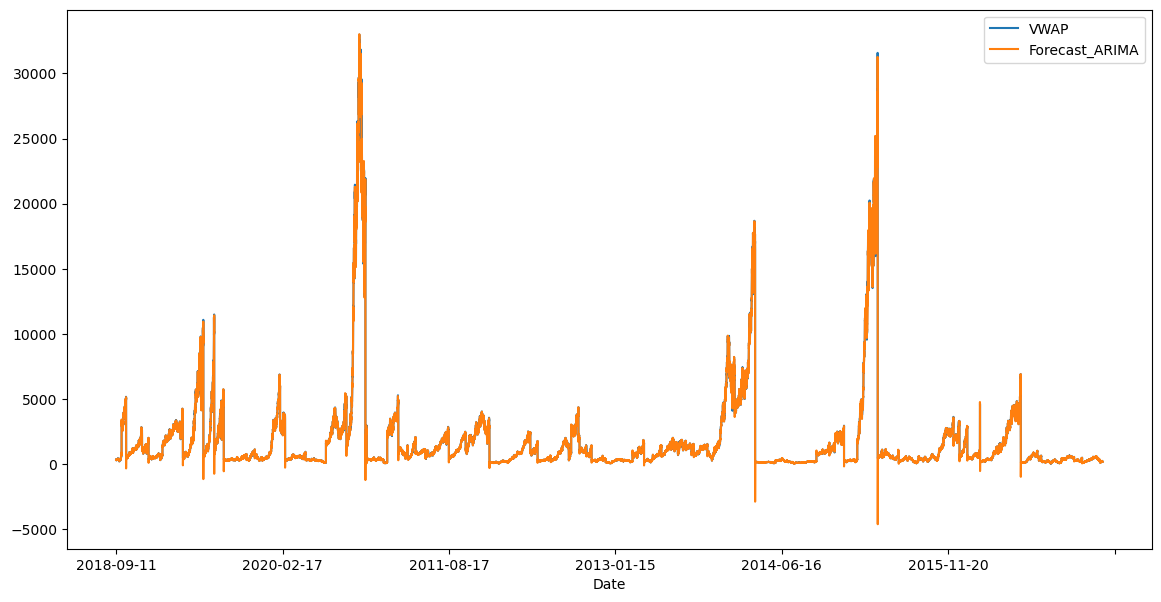

In [35]:
test_data[['VWAP','Forecast_ARIMA']].plot(figsize=(14,7))

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [37]:
np.sqrt(mean_squared_error(test_data['VWAP'],test_data['Forecast_ARIMA']))

112.12046702111458

In [38]:
mean_absolute_error(test_data['VWAP'],test_data['Forecast_ARIMA'])

19.839456807157127

In [39]:
print(test_data['VWAP'].describe())

count    118538.000000
mean       1815.300625
std        3461.038962
min          60.840000
25%         340.252500
50%         728.760000
75%        1808.215000
max       32975.240000
Name: VWAP, dtype: float64


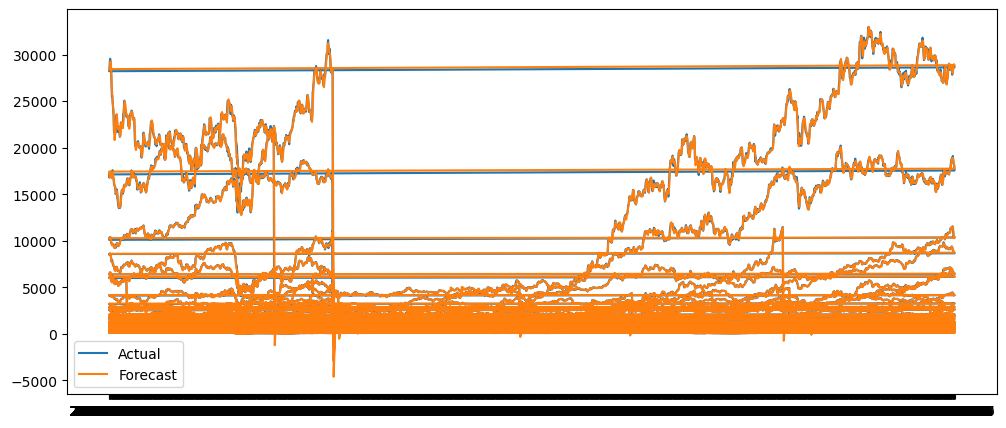

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(test_data['VWAP'], label='Actual')
plt.plot(test_data['Forecast_ARIMA'], label='Forecast')
plt.legend()
plt.show()

In [41]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    test_data['VWAP'],
    test_data['Forecast_ARIMA']
)

print(mape * 100)

1.5587223697177501


In [42]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1800
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -4582.177
Date:                Thu, 23 Jul 2026   AIC                           9214.355
Time:                        19:38:29   BIC                           9351.743
Sample:                             0   HQIC                          9265.070
                               - 1800                                         
Covariance Type:                  opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Highrolling_mean_3         0.3060   1.72e-26   1.78e+25      0.000       0.306       0.306
Highrolling_mean_7         0.2084   1.72e-26   1.21e+25      0.000       0.208       0.208
Lowr

In [43]:
test_data['VWAP'].describe()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1800
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -4582.177
Date:                Thu, 23 Jul 2026   AIC                           9214.355
Time:                        19:38:29   BIC                           9351.743
Sample:                             0   HQIC                          9265.070
                               - 1800                                         
Covariance Type:                  opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Highrolling_mean_3         0.3060   1.72e-26   1.78e+25      0.000       0.306       0.306
Highrolling_mean_7         0.2084   1.72e-26   1.21e+25      0.000       0.208       0.208
Lowr

In [44]:
print(training_data.shape)
print(test_data.shape)

(1800, 34)
(118538, 35)


In [45]:
print(test_data['VWAP'].min())
print(test_data['VWAP'].max())
print(test_data['VWAP'].mean())

60.84
32975.24
1815.3006246941711


In [46]:
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1800
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -4582.177
Date:                Thu, 23 Jul 2026   AIC                           9214.355
Time:                        19:38:29   BIC                           9351.743
Sample:                             0   HQIC                          9265.070
                               - 1800                                         
Covariance Type:                  opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Highrolling_mean_3         0.3060   1.72e-26   1.78e+25      0.000       0.306       0.306
Highrolling_mean_7         0.2084   1.72e-26   1.21e+25      0.000       0.208       0.208
Lowr

In [47]:
from sklearn.metrics import r2_score

r2 = r2_score(test_data['VWAP'], test_data['Forecast_ARIMA'])
print(r2)

0.9989505530652604
